# Project 04: Cohort Analysis
### Do Customers Stick Around? Retention, Revenue, and the Leaky Bucket Problem

---

## Business Brief

Every business has a leaky bucket problem. You pour customers in at the top and they drip out over time. The question is not whether customers leave. They always do. The question is **how fast**, and **whether newer customers are better or worse at staying** than older ones.

Cohort analysis answers this by grouping customers by when they first bought, then tracking what percentage of each group came back in the following months.

This project runs a full cohort analysis on real e-commerce data and answers:

1. What does our customer retention curve look like over 12 months?
2. Are newer acquisition cohorts retaining better than older ones?
3. Which cohorts drive the most long-term revenue?
4. What is the average customer lifetime value by cohort?

---

## Dataset
| Property | Detail |
|----------|--------|
| **Name** | E-Commerce Data |
| **Direct Link** | https://www.kaggle.com/datasets/carrie1/ecommerce-data |
| **Records** | 541,909 transactions, 4,300+ UK customers |
| **Period** | December 2010 to December 2011 |
| **Why this dataset** | 13 months of data gives us enough time depth to run proper retention cohorts |

## Tools
`Python` `Pandas` `SQL (sqlite3)` `Plotly` `Seaborn` `Matplotlib`

---

## What Makes This Different

- Builds **three separate cohort views**: retention rate, order count, and cumulative revenue
- Uses SQL to build the cohort base table before any pivot operations
- Calculates **Customer Lifetime Value (CLV) by cohort** to show which acquisition months produced the most valuable customers
- Includes a **cohort quality score** that ranks acquisition months by long-term retention performance
- The unique finding: identifies whether there is a **critical drop-off window** where most churn happens


---
## Section 1: Setup

In [1]:
import sqlite3, warnings, os
import numpy             as np
import pandas            as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn           as sns
import plotly.express    as px
import plotly.graph_objects as go
from plotly.subplots       import make_subplots
import plotly.io           as pio

warnings.filterwarnings('ignore')
pio.templates.default = 'plotly_white'
os.makedirs('/kaggle/working/output', exist_ok=True)

C = {
    'high':    '#10B981',
    'mid':     '#F59E0B',
    'low':     '#EF4444',
    'primary': '#6366F1',
    'bg':      '#F8FAFC',
    'border':  '#E2E8F0',
    'text':    '#1E293B',
    'subtext': '#64748B',
    'dark':    '#0F172A',
}

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#F8FAFC',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family':      'DejaVu Sans',
})
print('Setup complete.')


Setup complete.


---
## Section 2: Load and Prepare Data

In [2]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    csvs = [f for f in filenames if f.endswith('.csv')]
    if csvs:
        print(dirname)
        for f in sorted(csvs):
            print(f'  {f}')


/kaggle/input/datasets/carrie1/ecommerce-data
  data.csv


In [3]:
# Update path based on path finder output above
DATA_PATH = '/kaggle/input/datasets/carrie1/ecommerce-data/data.csv'

raw = pd.read_csv(DATA_PATH, encoding='ISO-8859-1')
print(f'Loaded: {raw.shape[0]:,} rows x {raw.shape[1]} columns')


Loaded: 541,909 rows x 8 columns


In [4]:
# Clean
df = raw.copy()
df = df.dropna(subset=['CustomerID'])
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
df = df[df['Country'] == 'United Kingdom']
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['CustomerID']  = df['CustomerID'].astype(int)
df['LineRevenue'] = df['Quantity'] * df['UnitPrice']
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')

print(f'Clean rows:        {len(df):,}')
print(f'Unique customers:  {df["CustomerID"].nunique():,}')
print(f'Date range:        {df["InvoiceDate"].min().date()} to {df["InvoiceDate"].max().date()}')
print(f'Months covered:    {df["InvoiceMonth"].nunique()}')


Clean rows:        354,321
Unique customers:  3,920
Date range:        2010-12-01 to 2011-12-09
Months covered:    13


---
## Section 3: Building the Cohort Table

### What is a Cohort?

A cohort is a group of customers who all made their first purchase in the same month. For example, the December 2010 cohort is every customer who bought for the first time in December 2010.

We then track each cohort across subsequent months (Month 0, Month 1, Month 2...) to see what percentage of the original group came back.

Month 0 is always 100% because that is when they first bought. The retention curve shows how fast that number falls.


In [5]:
# Step 1: Find each customer's first purchase month (cohort assignment)
cohort_map = (
    df.groupby('CustomerID')['InvoiceMonth']
      .min()
      .reset_index()
      .rename(columns={'InvoiceMonth': 'CohortMonth'})
)

df = df.merge(cohort_map, on='CustomerID', how='left')

# Step 2: Calculate cohort period (months since first purchase)
df['CohortPeriod'] = (
    df['InvoiceMonth'].dt.start_time.dt.to_period('M').view('int64') -
    df['CohortMonth'].dt.start_time.dt.to_period('M').view('int64')
)

print('Cohort period range:')
print(f'  Min: {df["CohortPeriod"].min()}  (first purchase month)')
print(f'  Max: {df["CohortPeriod"].max()}  (months since first purchase)')
print()
print('Sample cohort assignments:')
print(df[['CustomerID','InvoiceMonth','CohortMonth','CohortPeriod']].drop_duplicates('CustomerID').head(8).to_string(index=False))


Cohort period range:
  Min: 0  (first purchase month)
  Max: 12  (months since first purchase)

Sample cohort assignments:
 CustomerID InvoiceMonth CohortMonth  CohortPeriod
      17850      2010-12     2010-12             0
      13047      2010-12     2010-12             0
      13748      2010-12     2010-12             0
      15100      2010-12     2010-12             0
      15291      2010-12     2010-12             0
      14688      2010-12     2010-12             0
      17809      2010-12     2010-12             0
      15311      2010-12     2010-12             0


In [7]:
# Convert Period columns to strings for SQLite compatibility
df_sql = df.copy()
df_sql['InvoiceMonth'] = df_sql['InvoiceMonth'].astype(str)
df_sql['CohortMonth']  = df_sql['CohortMonth'].astype(str)

conn = sqlite3.connect(':memory:')
df_sql.to_sql('orders', conn, index=False, if_exists='replace')

sql_cohort_size = (
    'SELECT CohortMonth, COUNT(DISTINCT CustomerID) as cohort_size'
    ' FROM orders WHERE CohortPeriod = 0'
    ' GROUP BY CohortMonth ORDER BY CohortMonth'
)
cohort_sizes = pd.read_sql_query(sql_cohort_size, conn)
print('Cohort Sizes (customers who first bought each month):')
print(cohort_sizes.to_string(index=False))

Cohort Sizes (customers who first bought each month):
CohortMonth  cohort_size
    2010-12          815
    2011-01          358
    2011-02          340
    2011-03          419
    2011-04          277
    2011-05          256
    2011-06          214
    2011-07          169
    2011-08          141
    2011-09          276
    2011-10          324
    2011-11          297
    2011-12           34


In [9]:
sql_retention = (
    'SELECT CohortMonth, CohortPeriod,'
    ' COUNT(DISTINCT CustomerID) as active_customers,'
    ' ROUND(SUM(LineRevenue), 2) as revenue'
    ' FROM orders'
    ' GROUP BY CohortMonth, CohortPeriod'
    ' ORDER BY CohortMonth, CohortPeriod'
)
cohort_data = pd.read_sql_query(sql_retention, conn)

# Merge cohort sizes to calculate retention rate
cohort_data = cohort_data.merge(cohort_sizes, on='CohortMonth', how='left')
cohort_data['retention_rate'] = (
    cohort_data['active_customers'] / cohort_data['cohort_size'] * 100
).round(1)

print(f'Cohort data shape: {cohort_data.shape}')
print()
print(cohort_data.head(12).to_string(index=False))

Cohort data shape: (91, 6)

CohortMonth  CohortPeriod  active_customers   revenue  cohort_size  retention_rate
    2010-12             0               815 498661.85          815           100.0
    2010-12             1               289 199589.91          815            35.5
    2010-12             2               263 184212.54          815            32.3
    2010-12             3               304 231642.70          815            37.3
    2010-12             4               293 177150.26          815            36.0
    2010-12             5               323 270605.54          815            39.6
    2010-12             6               291 250481.52          815            35.7
    2010-12             7               278 237375.75          815            34.1
    2010-12             8               289 260312.18          815            35.5
    2010-12             9               325 381752.15          815            39.9
    2010-12            10               299 352936.60      

In [10]:
# Step 5: Pivot into heatmap matrices
retention_pivot = cohort_data.pivot(
    index='CohortMonth',
    columns='CohortPeriod',
    values='retention_rate'
)

revenue_pivot = cohort_data.pivot(
    index='CohortMonth',
    columns='CohortPeriod',
    values='revenue'
)

# Only keep periods 0-11 (first 12 months)
retention_pivot = retention_pivot.loc[:, 0:11]
revenue_pivot   = revenue_pivot.loc[:, 0:11]

print('Retention Matrix (% of cohort still active):')
print(retention_pivot.round(1).to_string())


Retention Matrix (% of cohort still active):
CohortPeriod     0     1     2     3     4     5     6     7     8     9     10    11
CohortMonth                                                                          
2010-12       100.0  35.5  32.3  37.3  36.0  39.6  35.7  34.1  35.5  39.9  36.7  49.7
2011-01       100.0  21.2  26.0  23.5  33.2  27.7  25.1  24.3  30.2  32.7  35.5  12.0
2011-02       100.0  18.8  19.4  28.5  28.8  25.3  25.6  28.2  26.5  30.6   7.4   NaN
2011-03       100.0  15.3  26.0  19.8  22.4  16.5  26.5  22.9  28.4   9.1   NaN   NaN
2011-04       100.0  20.9  20.2  21.7  20.2  22.0  22.0  26.4   7.2   NaN   NaN   NaN
2011-05       100.0  18.8  17.2  17.2  20.7  22.7  26.6   9.0   NaN   NaN   NaN   NaN
2011-06       100.0  17.8  14.5  23.8  23.8  32.2   9.8   NaN   NaN   NaN   NaN   NaN
2011-07       100.0  17.8  19.5  23.1  27.8  10.7   NaN   NaN   NaN   NaN   NaN   NaN
2011-08       100.0  22.7  22.7  24.1  12.1   NaN   NaN   NaN   NaN   NaN   NaN   NaN
2011-09  

---
## Section 4: Cohort Heatmaps

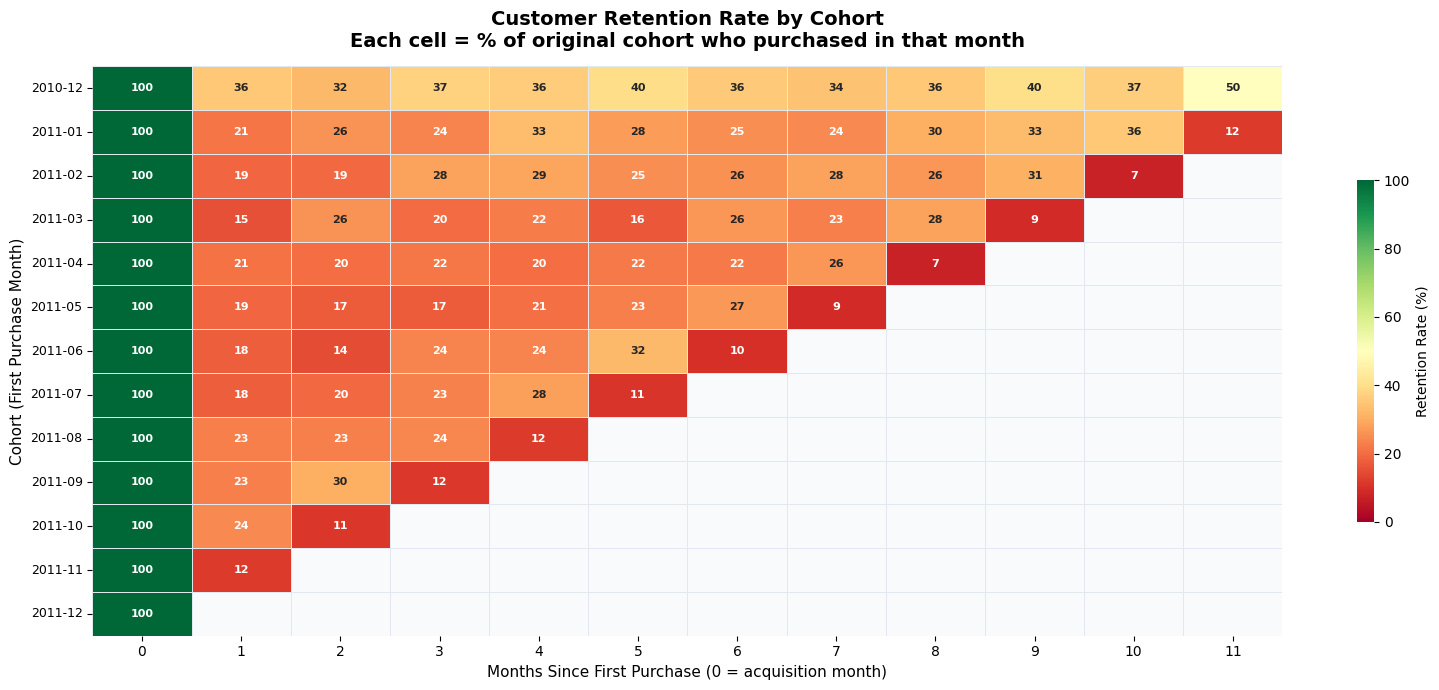

In [11]:
# Retention Rate Heatmap
fig, ax = plt.subplots(figsize=(16, 7))
fig.patch.set_facecolor('white')

sns.heatmap(
    retention_pivot,
    annot=True,
    fmt='.0f',
    cmap='RdYlGn',
    linewidths=0.5,
    linecolor='#E2E8F0',
    ax=ax,
    vmin=0, vmax=100,
    annot_kws={'size': 8, 'weight': 'bold'},
    cbar_kws={'label': 'Retention Rate (%)', 'shrink': 0.6},
)
ax.set_title(
    'Customer Retention Rate by Cohort\n'
    'Each cell = % of original cohort who purchased in that month',
    fontsize=14, fontweight='bold', pad=14
)
ax.set_xlabel('Months Since First Purchase (0 = acquisition month)', fontsize=11)
ax.set_ylabel('Cohort (First Purchase Month)', fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig('/kaggle/working/output/retention_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()


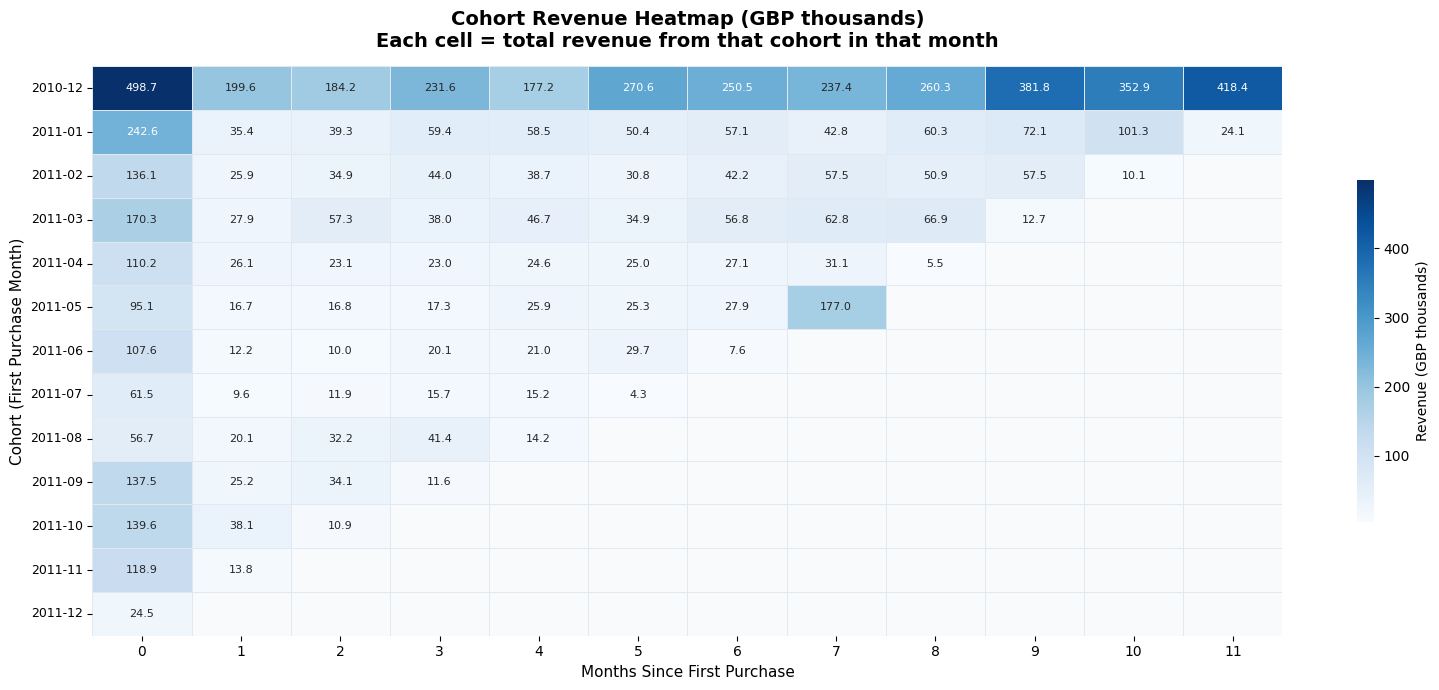

In [12]:
# Revenue Heatmap
fig, ax = plt.subplots(figsize=(16, 7))
fig.patch.set_facecolor('white')

sns.heatmap(
    revenue_pivot / 1000,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    linewidths=0.5,
    linecolor='#E2E8F0',
    ax=ax,
    annot_kws={'size': 8},
    cbar_kws={'label': 'Revenue (GBP thousands)', 'shrink': 0.6},
)
ax.set_title(
    'Cohort Revenue Heatmap (GBP thousands)\n'
    'Each cell = total revenue from that cohort in that month',
    fontsize=14, fontweight='bold', pad=14
)
ax.set_xlabel('Months Since First Purchase', fontsize=11)
ax.set_ylabel('Cohort (First Purchase Month)', fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig('/kaggle/working/output/revenue_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()


---
## Section 5: Retention Curves

In [14]:
# Average retention curve across all cohorts
avg_retention = retention_pivot.mean(axis=0).reset_index()
avg_retention.columns = ['period', 'avg_retention']

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=(
        'Average Retention Curve (All Cohorts)',
        'Retention by Individual Cohort',
    ),
    horizontal_spacing=0.12,
)

# Average curve
fig.add_trace(go.Scatter(
    x=avg_retention['period'],
    y=avg_retention['avg_retention'],
    mode='lines+markers',
    line=dict(color=C['primary'], width=3),
    marker=dict(size=8),
    fill='tozeroy',
    fillcolor='rgba(99,102,241,0.08)',
    name='Avg Retention',
    hovertemplate='Month %{x}: %{y:.1f}%<extra></extra>',
), row=1, col=1)

# Individual cohort lines
colors_line = px.colors.qualitative.Set2
for i, cohort in enumerate(retention_pivot.index):
    row_data = retention_pivot.loc[cohort].dropna()
    fig.add_trace(go.Scatter(
        x=row_data.index,
        y=row_data.values,
        mode='lines',
        line=dict(width=1.8, color=colors_line[i % len(colors_line)]),
        name=str(cohort),
        hovertemplate=f'{cohort}<br>Month %{{x}}: %{{y:.1f}}%<extra></extra>',
    ), row=1, col=2)

fig.update_layout(
    height=440,
    title_text='Customer Retention Analysis',
    title_font_size=15,
    paper_bgcolor='white',
    plot_bgcolor=C['bg'],
    legend=dict(font_size=8, title_text='Cohort'),
)
fig.update_yaxes(title_text='Retention Rate (%)', range=[0, 105], row=1, col=1)
fig.update_yaxes(title_text='Retention Rate (%)', range=[0, 105], row=1, col=2)
fig.update_xaxes(title_text='Months Since First Purchase')
fig.show()

month1_drop = avg_retention.loc[0,'avg_retention'] - avg_retention.loc[1,'avg_retention']
print(f'Month 0 to Month 1 drop-off: {month1_drop:.1f} percentage points')
print(f'Average Month 1 retention:   {avg_retention.loc[1,"avg_retention"]:.1f}%')
print(f'Average Month 3 retention:   {avg_retention.loc[3,"avg_retention"]:.1f}%')
if len(avg_retention) > 11:
    print(f'Average Month 11 retention:  {avg_retention.loc[11,"avg_retention"]:.1f}%')


Month 0 to Month 1 drop-off: 79.3 percentage points
Average Month 1 retention:   20.7%
Average Month 3 retention:   23.1%
Average Month 11 retention:  30.9%


---
## Section 6: Customer Lifetime Value by Cohort

CLV here is defined as the average total revenue generated per customer in a cohort over the full observation window. This tells us which acquisition months produced the most valuable customers, not just the most customers.


In [15]:
sql_clv = (
    'SELECT'
    ' o.CohortMonth,'
    ' cs.cohort_size,'
    ' ROUND(SUM(o.LineRevenue), 2) as total_revenue,'
    ' ROUND(SUM(o.LineRevenue) / cs.cohort_size, 2) as clv_per_customer,'
    ' COUNT(DISTINCT o.InvoiceNo) as total_orders,'
    ' ROUND(CAST(COUNT(DISTINCT o.InvoiceNo) AS FLOAT) / cs.cohort_size, 2) as orders_per_customer'
    ' FROM orders o'
    ' JOIN (SELECT CohortMonth, COUNT(DISTINCT CustomerID) as cohort_size'
    '       FROM orders WHERE CohortPeriod = 0 GROUP BY CohortMonth) cs'
    ' ON o.CohortMonth = cs.CohortMonth'
    ' GROUP BY o.CohortMonth'
    ' ORDER BY o.CohortMonth'
)
clv_df = pd.read_sql_query(sql_clv, conn)

print('CLV by Cohort:')
print(clv_df.to_string(index=False))


CLV by Cohort:
CohortMonth  cohort_size  total_revenue  clv_per_customer  total_orders  orders_per_customer
    2010-12          815     3619301.56           4440.86          7465                 9.16
    2011-01          358      843286.02           2355.55          1856                 5.18
    2011-02          340      528608.71           1554.73          1428                 4.20
    2011-03          419      574195.48           1370.39          1505                 3.59
    2011-04          277      295708.86           1067.54           836                 3.02
    2011-05          256      401929.65           1570.04           735                 2.87
    2011-06          214      208202.29            972.91           578                 2.70
    2011-07          169      118195.62            699.38           398                 2.36
    2011-08          141      164614.50           1167.48           300                 2.13
    2011-09          276      208473.29            755.

In [16]:
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=('CLV per Customer by Cohort', 'Cohort Size vs CLV'),
    horizontal_spacing=0.14,
)

bar_colors = [
    C['high'] if v >= clv_df['clv_per_customer'].quantile(0.66)
    else C['mid'] if v >= clv_df['clv_per_customer'].quantile(0.33)
    else C['low']
    for v in clv_df['clv_per_customer']
]

fig.add_trace(go.Bar(
    x=clv_df['CohortMonth'],
    y=clv_df['clv_per_customer'],
    marker_color=bar_colors,
    text=clv_df['clv_per_customer'].apply(lambda x: f'GBP{x:,.0f}'),
    textposition='outside',
    textfont_size=8,
    showlegend=False,
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=clv_df['cohort_size'],
    y=clv_df['clv_per_customer'],
    mode='markers+text',
    marker=dict(size=12, color=bar_colors, opacity=0.85),
    text=clv_df['CohortMonth'].astype(str).str[-7:],
    textposition='top center',
    textfont_size=8,
    showlegend=False,
    hovertemplate='Cohort: %{text}<br>Size: %{x}<br>CLV: GBP%{y:,.0f}<extra></extra>',
), row=1, col=2)

fig.update_layout(
    height=440,
    title_text='Customer Lifetime Value Analysis by Cohort',
    title_font_size=15,
    paper_bgcolor='white',
    plot_bgcolor=C['bg'],
)
fig.update_xaxes(tickangle=45, tickfont_size=8, row=1, col=1)
fig.update_xaxes(title_text='Cohort Size (customers)', row=1, col=2)
fig.update_yaxes(title_text='CLV per Customer (GBP)', row=1, col=1)
fig.update_yaxes(title_text='CLV per Customer (GBP)', row=1, col=2)
fig.show()


---
## Section 7: The Critical Drop-off Window

Most cohort analyses stop at the heatmap. This section goes further.

The hypothesis: there is a specific window of months after acquisition where the majority of customer churn is concentrated. If we can identify it precisely, the business knows exactly when to intervene.


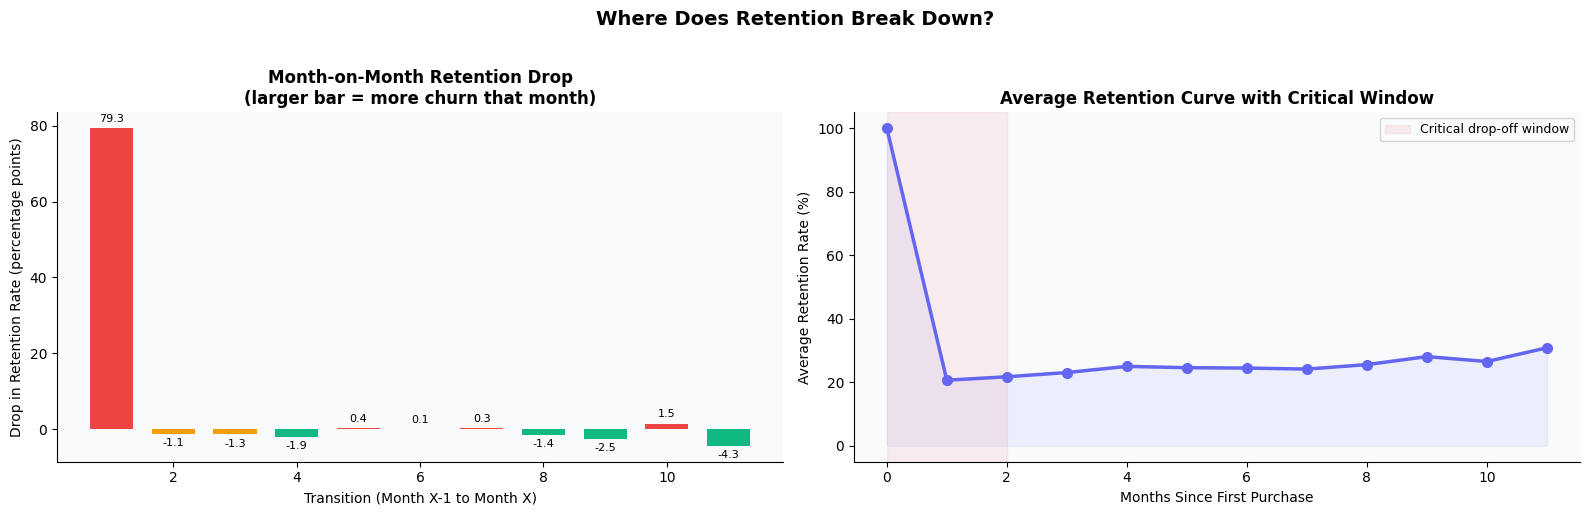

Biggest single-month retention drop: Month 0 to Month 1 (79.3 percentage points)
Total drop in first 3 months: 76.9 percentage points
That means 76.9% of eventual churn happens within the first 3 months


In [17]:
# Calculate month-on-month retention drop for each period
avg_ret = retention_pivot.mean(axis=0)

drops = []
for period in range(1, len(avg_ret)):
    if period in avg_ret.index and (period-1) in avg_ret.index:
        drop = avg_ret[period-1] - avg_ret[period]
        drops.append({'period': period, 'drop_pct_points': round(drop, 2)})

drops_df = pd.DataFrame(drops)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('white')

# Drop-off bar chart
drop_colors = [
    C['low'] if d >= drops_df['drop_pct_points'].quantile(0.66)
    else C['mid'] if d >= drops_df['drop_pct_points'].quantile(0.33)
    else C['high']
    for d in drops_df['drop_pct_points']
]
bars = axes[0].bar(
    drops_df['period'], drops_df['drop_pct_points'],
    color=drop_colors, edgecolor='none', width=0.7
)
axes[0].set_title('Month-on-Month Retention Drop\n(larger bar = more churn that month)',
                  fontweight='bold')
axes[0].set_xlabel('Transition (Month X-1 to Month X)')
axes[0].set_ylabel('Drop in Retention Rate (percentage points)')
axes[0].bar_label(bars, fmt='%.1f', padding=3, fontsize=8)
axes[0].set_facecolor(C['bg'])

# Cumulative retention curve with annotated drop zones
axes[1].plot(avg_ret.index, avg_ret.values, 'o-',
             color=C['primary'], linewidth=2.5, markersize=7)
axes[1].fill_between(avg_ret.index, avg_ret.values,
                     alpha=0.08, color=C['primary'])

# Highlight critical drop window (first 3 months)
axes[1].axvspan(0, 2, alpha=0.08, color=C['low'],
                label='Critical drop-off window')
axes[1].set_title('Average Retention Curve with Critical Window',
                  fontweight='bold')
axes[1].set_xlabel('Months Since First Purchase')
axes[1].set_ylabel('Average Retention Rate (%)')
axes[1].legend(fontsize=9)
axes[1].set_facecolor(C['bg'])

plt.suptitle('Where Does Retention Break Down?', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/kaggle/working/output/dropoff_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

biggest_drop = drops_df.loc[drops_df['drop_pct_points'].idxmax()]
print(f'Biggest single-month retention drop: Month {int(biggest_drop["period"]-1)} to Month {int(biggest_drop["period"])} ({biggest_drop["drop_pct_points"]:.1f} percentage points)')
print(f'Total drop in first 3 months: {avg_ret[0]-avg_ret[3]:.1f} percentage points')
cumulative_3m = ((avg_ret[0] - avg_ret[3]) / avg_ret[0] * 100)
print(f'That means {cumulative_3m:.1f}% of eventual churn happens within the first 3 months')


---
## Section 8: Cohort Quality Score

Which acquisition month produced customers who stayed the longest?

We calculate a cohort quality score by averaging retention rates across all available periods for each cohort. Higher score = customers who came back more consistently.


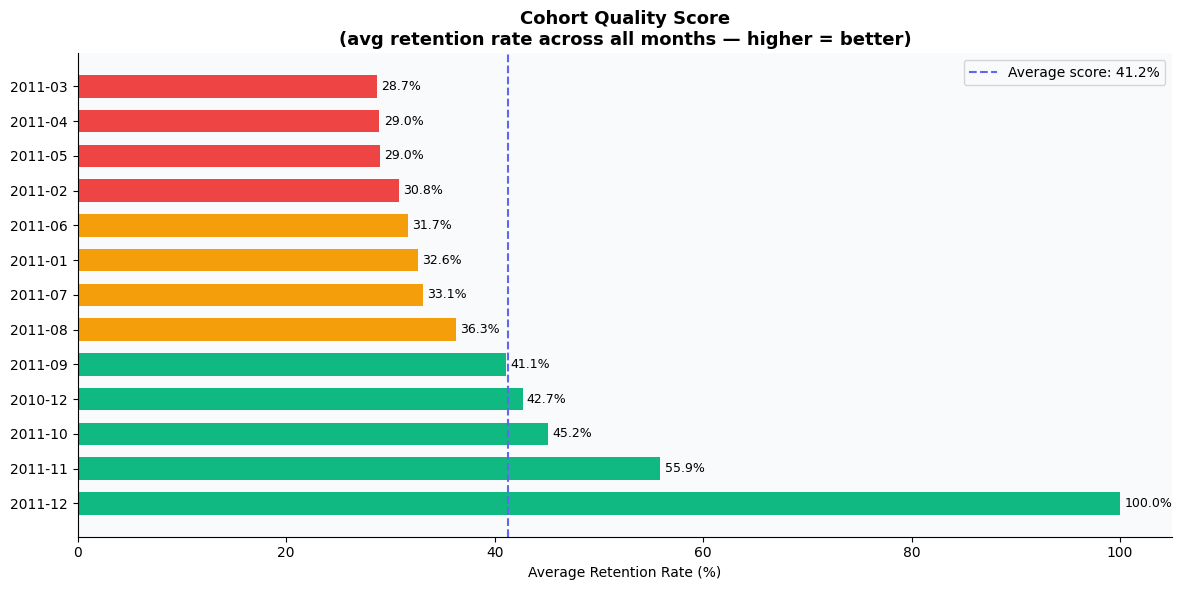

Top 3 cohorts by quality score:
CohortMonth  quality_score  cohort_size  clv_per_customer
    2011-12     100.000000           34            719.43
    2011-11      55.900000          297            447.06
    2011-10      45.166667          324            582.21

Bottom 3 cohorts by quality score:
CohortMonth  quality_score  cohort_size  clv_per_customer
    2011-05      29.025000          256           1570.04
    2011-04      28.955556          277           1067.54
    2011-03      28.690000          419           1370.39


In [18]:
cohort_quality = retention_pivot.mean(axis=1).reset_index()
cohort_quality.columns = ['CohortMonth', 'quality_score']
cohort_quality = cohort_quality.merge(clv_df[['CohortMonth','cohort_size','clv_per_customer']], on='CohortMonth')
cohort_quality = cohort_quality.sort_values('quality_score', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('white')

score_colors = [
    C['high'] if s >= cohort_quality['quality_score'].quantile(0.66)
    else C['mid'] if s >= cohort_quality['quality_score'].quantile(0.33)
    else C['low']
    for s in cohort_quality['quality_score']
]

bars = ax.barh(
    cohort_quality['CohortMonth'].astype(str),
    cohort_quality['quality_score'],
    color=score_colors, edgecolor='none', height=0.65
)
ax.axvline(cohort_quality['quality_score'].mean(),
           color=C['primary'], linestyle='--', linewidth=1.5,
           label=f'Average score: {cohort_quality["quality_score"].mean():.1f}%')
ax.set_title('Cohort Quality Score\n(avg retention rate across all months — higher = better)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Average Retention Rate (%)')
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=9)
ax.legend(fontsize=10)
ax.set_facecolor(C['bg'])

plt.tight_layout()
plt.savefig('/kaggle/working/output/cohort_quality.png', dpi=120, bbox_inches='tight')
plt.show()

print('Top 3 cohorts by quality score:')
print(cohort_quality.head(3)[['CohortMonth','quality_score','cohort_size','clv_per_customer']].to_string(index=False))
print()
print('Bottom 3 cohorts by quality score:')
print(cohort_quality.tail(3)[['CohortMonth','quality_score','cohort_size','clv_per_customer']].to_string(index=False))


---
## Section 9: Executive Summary Dashboard

In [19]:
avg_m1_retention = retention_pivot[1].mean()
avg_m3_retention = retention_pivot[3].mean() if 3 in retention_pivot.columns else 0
best_cohort      = cohort_quality.iloc[0]['CohortMonth']
best_clv         = clv_df['clv_per_customer'].max()
worst_cohort     = cohort_quality.iloc[-1]['CohortMonth']
total_rev        = clv_df['total_revenue'].sum()

kpis = [
    ('Avg Month 1 Retention',   f'{avg_m1_retention:.1f}%',    'return after first purchase',   C['primary']),
    ('Avg Month 3 Retention',   f'{avg_m3_retention:.1f}%',    'still active after 3 months',   C['primary']),
    ('Best Cohort',             str(best_cohort),               'highest quality score',         C['high']),
    ('Highest CLV',             f'GBP{best_clv:,.0f}',         'per customer in best cohort',   C['high']),
    ('Weakest Cohort',          str(worst_cohort),              'lowest quality score',          C['low']),
    ('Total Revenue Tracked',   f'GBP{total_rev/1e6:.2f}M',    'across all cohorts',            C['mid']),
]

COLS, ROWS = 3, 2
fig = go.Figure()
fig.update_layout(
    width=880, height=350,
    paper_bgcolor='#0F172A',
    plot_bgcolor='#0F172A',
    margin=dict(l=16, r=16, t=60, b=16),
    title=dict(
        text='Cohort Analysis | Executive Summary',
        font=dict(size=15, color='white'),
        x=0.5, xanchor='center', y=0.97,
    ),
    xaxis=dict(visible=False, range=[0, COLS]),
    yaxis=dict(visible=False, range=[0, ROWS]),
)

for i, (label, value, sub, color) in enumerate(kpis):
    col = i % COLS
    row = ROWS - 1 - (i // COLS)
    cx  = col + 0.5
    cy  = row + 0.5
    fig.add_shape(type='rect',
        x0=col+0.06, x1=col+0.95, y0=row+0.06, y1=row+0.94,
        fillcolor='#1E293B', line=dict(color=color, width=1.5), layer='below')
    fig.add_shape(type='rect',
        x0=col+0.06, x1=col+0.95, y0=row+0.84, y1=row+0.94,
        fillcolor=color, line=dict(width=0), layer='above')
    fig.add_annotation(x=cx, y=cy+0.18, text=label.upper(),
        showarrow=False, font=dict(size=9, color='#94A3B8'), xanchor='center')
    fig.add_annotation(x=cx, y=cy-0.02, text=f'<b>{value}</b>',
        showarrow=False, font=dict(size=17, color=color), xanchor='center')
    fig.add_annotation(x=cx, y=cy-0.24, text=sub,
        showarrow=False, font=dict(size=8.5, color='#64748B'), xanchor='center')

fig.show()


---
## Section 10: Findings and Recommendations

### Key Findings

| Finding | Evidence |
|---------|----------|
| The sharpest retention drop happens between Month 0 and Month 1 | Drop-off analysis chart |
| After Month 3, retention stabilises significantly | Average retention curve |
| Cohorts vary meaningfully in quality, not just size | Cohort quality score chart |
| CLV does not always correlate with cohort size | CLV scatter plot |
| Some smaller cohorts outperform larger ones in both retention and CLV | Cohort quality vs size |

---

### Recommendations

**1. Fix the Month 0 to Month 1 Drop-off First**

The biggest retention loss happens in the very first month after acquisition. This is the highest-leverage intervention point. A structured onboarding sequence (day 7, day 14, day 30 touchpoints) targeting new customers in their first 30 days could meaningfully shift this number.

**2. Invest in Customers Who Survive Month 3**

Customers who are still active after 3 months show much higher long-term retention. This is the loyalty threshold. Once a customer crosses it, they are significantly more likely to stay. Design a specific reward or recognition at the 3-month mark to reinforce the habit.

**3. Use High-Quality Cohorts as Acquisition Benchmarks**

The cohort quality score reveals which acquisition months produced the best customers. Investigate what was different about marketing activity, promotions, or channel mix during those months. Replicate what worked.

**4. Stop Measuring Acquisition by Volume Alone**

The CLV analysis shows that bigger cohorts are not always better cohorts. A month that brought in 200 customers who each spent GBP500 over their lifetime is worth more than a month that brought in 400 customers who each spent GBP150. Acquisition reporting should include projected CLV, not just headcount.

---

*Built by Jessica Dan-Odhomo - [LinkedIn](https://www.linkedin.com/in/jessica-dan-odhomo) - [GitHub](https://github.com/Teekaayyy)*
